In [1]:
import os
%config InlineBackend.figure_format = 'png'
import numpy as np
from getdist import plots, types
from getdist.mcsamples import loadMCSamples
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,          # <--- APAGADO para que no busque latex
    "font.family": "serif",
    "font.serif": ["cmr10"],       # cmr10 es "Computer Modern Roman" interno
    "mathtext.fontset": "cm",      # Configura las matemáticas para usar Computer Modern
    "axes.formatter.use_mathtext": True # Usa mathtext para los números de los ejes
})

In [2]:
base_dir = '/Volumes/PortableSSD/MacOS/CursoBAO/CPE/Cobaya/Chains'

## Our Likelihood ##
Ruta1 = os.path.join(base_dir,'OurChain')
Ruta1_v2 = os.path.join(base_dir,'OurBadChain')
## DESI Public Likelihood  ##
Ruta2 = os.path.join(base_dir, 'DESIChain')

In [ ]:
# Charging the chains
our_sample = loadMCSamples(Ruta1, no_cache=False)
our_bad_sample = loadMCSamples(Ruta1_v2, no_cache=False)
DESI_sample = loadMCSamples(Ruta2, no_cache=False)

In [4]:
print(DESI_sample.getGelmanRubin())
print(our_sample.getGelmanRubin())
print(our_bad_sample.getGelmanRubin())

0.0008097218813007271
0.00027724074474177877
0.00018164457151401717


In [ ]:
# Adding labels to the samples
our_sample.label = "Our Likelihood"
our_bad_sample.label = "Our Bad Likelihood"
DESI_sample.label = "DESI Public Likelihood"

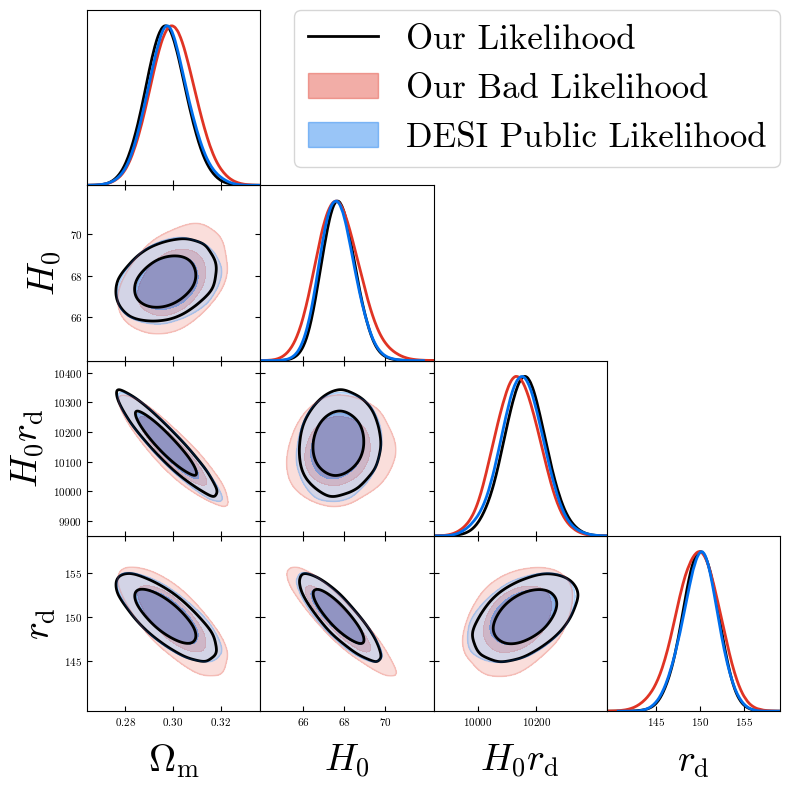

In [ ]:
# Plotting triangular plot
g = plots.get_subplot_plotter()
g.settings.legend_fontsize = 28
g.settings.alpha_filled_add=0.4
g.settings.lab_fontsize = 30

chains = [
        our_sample,
        our_bad_sample, 
          DESI_sample
          ]

g.triangle_plot(chains,
                ['Omega_m', 'H0', 'H0rdrag', 'rs_drag'],
                # ['As', 'ns'],
                legend_loc= 'upper right',
                contour_ls= ['-', '-'],
                contour_lws= [2,2,2],
                markers={'omk':0, 'mnu':0.06}, 
                marker_args={'lw': 3},
                filled=[False, True])

((9877.530048427074, 10441.063151572927),
 (0.2656036794375596, 0.3314953505624404))

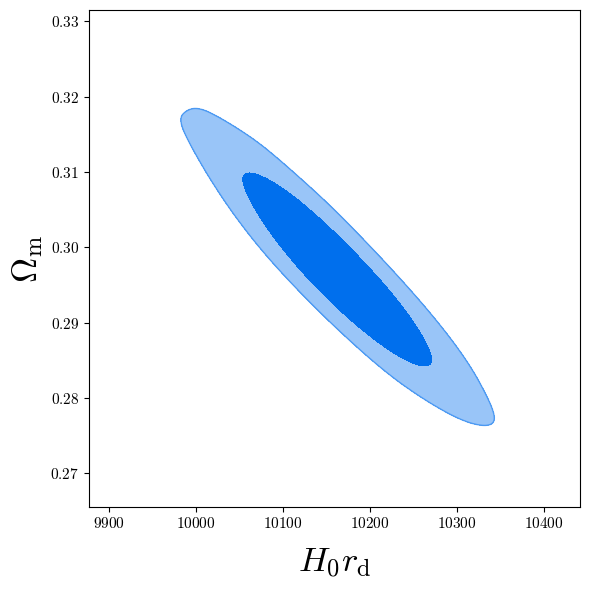

In [ ]:
# Plotting 2D plot
g = plots.get_single_plotter(width_inch=6, ratio=1)
g.settings.legend_fontsize = 12
g.settings.lab_fontsize = 25

chains = [our_sample]

g.plot_2d(chains, 
           "H0rdrag", "Omega_m",
        #    "H0", "sum_nu",
          filled=[True, False, True], 
          # lims=[67,71, -0.15,0.06], 
          ls=['-','--','-'])